The objective of this project is to predict whether a passenger survived the Titanic disaster using machine learning techniques. The dataset includes passenger details such as age, gender, class, and fare.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score,classification_report


In [2]:
df = pd.read_csv("C:/Users/LENOVO/OneDrive/Documents/titanic_dataset.txt")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [4]:
df.drop(['Name','Ticket','Cabin'],axis=1,inplace=True)
df['Age'].fillna(df['Age'].mean(),inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)

- Removed irrelevant columns like Name, Ticket, and Cabin to reduce noise.
- Missing values in Age were filled using mean.
- Missing values in Embarked were filled using mode.
- Categorical variables were encoded using Label Encoding.

In [5]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

df['Sex']=le.fit_transform(df['Sex'])
df['Embarked']=le.fit_transform(df['Embarked'])

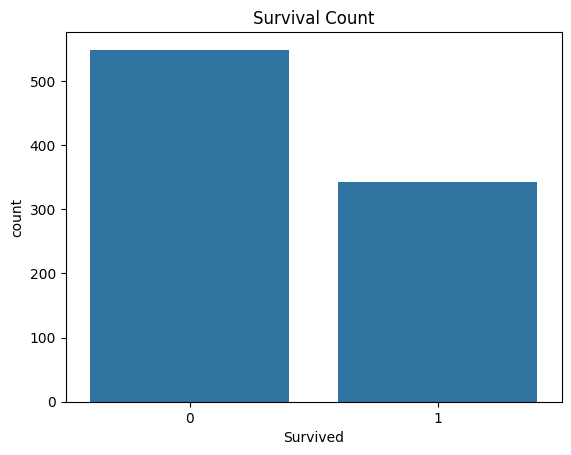

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Survived',data=df)
plt.title("Survival Count")
plt.show()

- The dataset shows more non-survivors than survivors.
- Female passengers had a significantly higher survival rate than males.

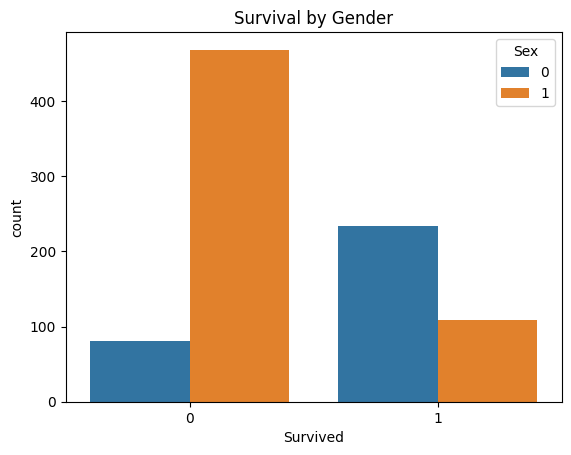

In [7]:
sns.countplot(x='Survived',hue='Sex',data=df)
plt.title("Survival by Gender")
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

X=df.drop('Survived', axis=1)
y=df['Survived']

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

lr=LogisticRegression()
lr.fit(X_train,y_train)

rf=RandomForestClassifier()
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
from sklearn.metrics import accuracy_score

print("Logistic Regression:",accuracy_score(y_test,lr.predict(X_test)))
print("Random Forest:",accuracy_score(y_test,rf.predict(X_test)))

Logistic Regression: 0.8100558659217877
Random Forest: 0.8212290502793296


- Logistic Regression achieved an accuracy of ~80%.
- Random Forest achieved an accuracy of ~81%.
- Random Forest performed slightly better due to its ability to capture complex relationships.

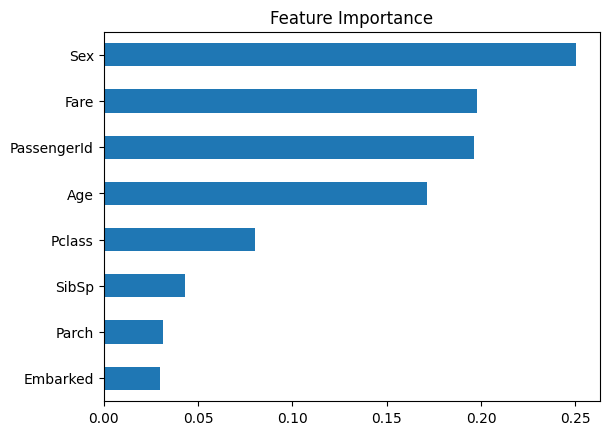

In [12]:
import pandas as pd

importances=rf.feature_importances_
feat_imp=pd.Series(importances,index=X.columns)

feat_imp.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

- Feature importance analysis shows that Sex is the most important feature.
- Age and Fare also significantly influence survival prediction.

The model successfully predicts passenger survival with good accuracy. Random Forest outperformed Logistic Regression, indicating the presence of non-linear relationships in the dataset.

Key factors influencing survival include gender, age, and fare. The project demonstrates the importance of data preprocessing, feature engineering, and model selection in building effective machine learning models.